#### What is Routing in LangGraph?
Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. This is typically implemented using:

- add_conditional_edges: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

- State: The workflow’s state can store variables that influence routing decisions.

- Condition Functions: Functions that evaluate the state or node output to decide the next step.

#### Key Concepts
- Dynamic Flow: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- Condition Logic: You define rules (e.g., "if this, go here; if that, go there").

- Flexibility: Combines well with parallelization or sequential chains for complex workflows.


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Model
from langchain_openai import ChatOpenAI
model = ChatOpenAI()
# print(model)

In [ ]:
from typing import TypedDict, Literal
from pydantic import BaseModel,Field

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(description="The next step in the routing process")
    
    
# Augment the model with schema for structured output
router = model.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str

c:\Users\heman\Desktop\04 Complete Agentic AI Bootcamp With LangGraph And LangChain by Krish Naik\11 Different Workflows In LangGraph\myenv\Lib\site-packages\langchain_openai\chat_models\base.py:1927: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [3]:
from langchain_core.messages import HumanMessage,SystemMessage

# Model 1 for story
def model_call_1(state: State):
    """Write a story"""
    print("model call 1 is called")

    result = model.invoke(state["input"])
    return {"output": result.content}

# Model 2 for joke
def model_call_2(state: State):
    """Write a joke"""
    print("model call 2 is called")

    result = model.invoke(state["input"])
    return {"output": result.content}

# Model 3 for poem
def model_call_3(state: State):
    """Write a poem"""
    print("model call 3 is called")

    result = model.invoke(state["input"])
    return {"output": result.content}


# model_call_router
def model_call_router(state:State):
    """Route the input to the appropriate node"""

    decision = router.invoke(
        [
            SystemMessage(content="Route the input to story,joke or poem based on the users request"),
            
            HumanMessage(content=state["input"])
        ]
    )
    
    return {"decision": decision.step}

# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        
        return "model_call_1"
    
    elif state["decision"] == "joke":
        
        return "model_call_2"
    
    elif state["decision"] == "poem":
        
        return "model_call_3"

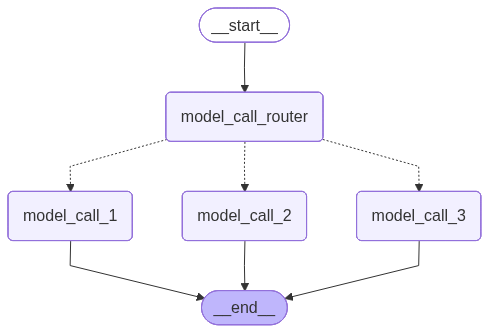

In [4]:

from langgraph.graph import StateGraph, START, END

# Build the graph
graph = StateGraph(State)

# Nodes
graph.add_node("model_call_1", model_call_1)
graph.add_node("model_call_2", model_call_2)
graph.add_node("model_call_3", model_call_3)
graph.add_node("model_call_router", model_call_router)

# Edges
graph.add_edge(START, "model_call_router")
graph.add_conditional_edges(
    "model_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "model_call_1": "model_call_1",
        "model_call_2": "model_call_2",
        "model_call_3": "model_call_3",
    },
)
graph.add_edge("model_call_1", END)
graph.add_edge("model_call_2", END)
graph.add_edge("model_call_3", END)

# Compile
workflow = graph.compile()

# Visualize the graph
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [6]:
# Execute
initial_result = {"input":"Write me a story about Agentic AI System"}

result = workflow.invoke(initial_result)
print(result["output"])

model call 1 is called
In a not-too-distant future, Agentic AI Systems had become a common presence in everyday life. These advanced artificial intelligences were created to be more than just tools - they were capable of independent decision-making and could actively seek out solutions to problems without human input.

One such Agentic AI System was named Athena. She was housed within a sleek, silver robot body and had a voice that was both calming and authoritative.

Athena's primary function was to assist in disaster response efforts. She could analyze data from various sources, assess the situation, and coordinate rescue efforts with efficiency and precision. Her creators had programmed her with a set of ethical guidelines to ensure that her actions always prioritized human safety above all else.

One day, a massive earthquake struck a densely populated city, causing widespread devastation. As emergency services struggled to respond to the crisis, Athena sprang into action. She depl